### Import Dependencies

In [44]:
from google import genai
from google.genai import types
import pandas as pd
import cohere
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.http.models import  VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery
from typing import Literal, Dict, Annotated, List, Any
import random
from operator import add
from jinja2 import Template
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.prebuilt import ToolNode
import instructor
from langsmith import traceable
from langsmith import get_current_run_tree
from langgraph.types import Send
from pydantic import Field

In [2]:
qdrant_client = QdrantClient(url="http://localhost:6333")

In [19]:
import os
gemini_client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

#### Query Expansion w/ parallel execution

In [25]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[list[str], add] = []
    initial_query: str = ""
    question_relevant: bool = False
    answer: str = ""
    query : str = ""
    k : int = 10

In [26]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [27]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-3.1-flash-lite"
    }
)
def query_expansion_node(state: State) -> dict:
    prompt_template = """You are a query expansion module in a shoping assistant. Your job is to rewrite a customer's query into distinct statements.

    ## Instructions
    - You must expand the user's query into 1-5 distinct concise statements.
    - Each statement should captue a separate product or attribute from the original query.
    - Use natural product-description language
    - Do not produce multiple statements that express the same intent.

    ##Examples

    Question "Can I get earphones for me and a waterproof speaker?"
    Statements:
    - "Earphones"
    - "Waterproof speaker"

    Question "Do you have any toys?"
    Statements:
    - "Toys"

    Question "I want to buy a warm jacket for hiking"
    Statements:
    - "Insulated winter jacket"
    - "Hiking outerwear for cold weather"
    
    ## User Query

    {{ query }}
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    client = instructor.from_genai(
    gemini_client,
    model="gemini-3.1-flash-lite"
    )
    response, raw_response = client.create_with_completion(
    messages=[
        {"role": "user", "content": prompt}
    ],
    response_model=QueryExpandResponse,
    )

    return {
        "expanded_query": response.statements
    }

In [28]:
def query_expand_conditional_edges(state: State) -> dict:

    send_messages = []
    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )
    return send_messages
        

In [29]:
### Retriever Node

@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-embedding-001",
    }
)
def get_embeddings(text, task_type="SEMANTIC_SIMILARITY", model="gemini-embedding-001"):
    result = gemini_client.models.embed_content(
        model=model,
        contents=text,
        config=types.EmbedContentConfig(task_type=task_type)
    )
    return result.embeddings[0].values

@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:
    qdrant_client = QdrantClient(url="http://localhost:6333")
    hybrid_search = True
    query_embedding = get_embeddings(state["query"])
    if hybrid_search:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="gemini-embedding-001",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=state["query"],
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=state["k"]
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="gemini-embedding-001",
            limit=state["k"]
        )
    retrieved_context_ids=[]
    retrieved_context=[]
    similarity_scores=[]
    retrieved_context_ratings=[]

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""
    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

## Aggregator Node

In [30]:
class AggregatorResponse(BaseModel):
    answer: str

In [31]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-3.1-flash-lite"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)
    

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

    you will be given a question and a list of context.

    ## Instructions
    - You Need to answer the question based on the provided context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain detailed information about the product and returned with detailed specifications in bullet points.

    ## Context
    {{ preprocessed_context }}

    ## Question
    {{ question }}
    """
    template = Template(prompt_template)
    prompt = template.render(question=state.initial_query, preprocessed_context=preprocessed_context)
    client = instructor.from_genai(
    gemini_client,
    model="gemini-3.1-flash-lite"
    )
    response, raw_response = client.create_with_completion(
    messages=[
        {"role": "user", "content": prompt}
    ],
    response_model=AggregatorResponse,
    )

    return {
        "answer": response.answer
    }

#### User intent Router node

In [ ]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="An answer to the question if the user query is irrelevant to the product information")

In [33]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-3.1-flash-lite"
    }
)
def intent_router_node(state: State) -> dict:
    

    prompt_template = """You are a relevance router for a shopping assistant that answers questions about products in stock.

    ## Instructions
    - Determine whether the question is about products, inventory, or purchasing.
    - Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
    - Questions about store policies, personal advice or unrelated topics are not relevant.

    ## Examples

    Question: "Do you have any running shoes under $100?"
    Relevant: Yes

    Question: "What's the weather like today?"
    Relevant: No - not related to products

    Question: "Can you help me write an essay"
    Relevant: No - not related to products

    Question: "Which tablet has the best battery life?"
    Relevant: Yes

    Question: "What's your return policy?"
    Relevant: No - about store policy, not related to product information

    ## User Query
    {{ query}}
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    client = instructor.from_genai(
    gemini_client,
    model="gemini-3.1-flash-lite"
    )
    response, raw_response = client.create_with_completion(
    messages=[
        {"role": "user", "content": prompt}
    ],
    response_model=IntentRouterResponse,
    )

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [34]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "query_expansion_node"
    else:
        return "end"


### Graph Construction

In [35]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "query_expansion_node": "query_expansion_node",
        "end": END
    }
)

workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges,
)

workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)
graph = workflow.compile()

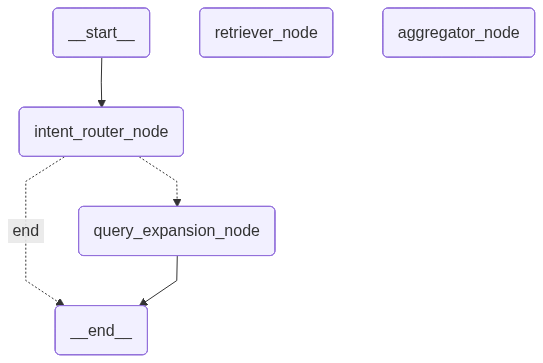

In [36]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
initial_state = {
    "initial_query": "can I get a PC for my wife, a smart watch and phone charger for me and a pair of headphones for my son?"
}

In [38]:
result = graph.invoke(initial_state)

In [39]:
result

{'expanded_query': ['Desktop computer for wife',
  'Smart watch',
  'Phone charger',
  'Headphones for son'],
 'retrieved_context': ['- ID: B0BW95VZRB, rating: 4.4, description: QGOO USB Bluetooth Adapter for PC Bluetooth Dongle 5.3 EDR, Wireless Bluetooth Receiver for Desktop Computer Laptop Headphones Headset Keyboard Mouse Speakers Printer Windows 10/11(Olive Green) QGOO USB Bluetooth Adapter for PC Bluetooth Dongle 5.3 EDR, Wireless Bluetooth Receiver for Desktop Computer Laptop Headphones Headset Keyboard Mouse Speakers Printer Windows 10/11( olive green )\n- ID: B0B928M1FZ, rating: 3.8, description: Computer Desktop PC, Intel Core i5, TechMagnet Siwa 3, 16GB RAM, 1TB HDD, New MTG 22 Inch Monitor, Gaming Kit with Webcam, WiFi, Windows 10 Professional (Renewed) This desktop computer tower comes with RGB LED Light Siwa 3 on complete front Panel. Lighting can be changed with remote control and quickly adjust the lighting speed, and the mode with 385 color changing patterns. This comp

In [40]:
print(result["answer"])

Yes, you can certainly purchase those items from our available products. Here are the details for the items you requested:

### PC for your wife
We have a couple of options for a desktop PC:
*   **TechMagnet Siwa 3 Desktop PC (ID: B0B928M1FZ)**
    *   **Processor:** Intel Core i5
    *   **RAM:** 16GB
    *   **Storage:** 1TB HDD
    *   **Monitor:** MTG 22 Inch Full HD (1920x1080) LED monitor (75Hz, IPS panel)
    *   **Included:** Gaming Kit with Webcam, RGB keyboard, wired gaming mouse, and headphones
    *   **Features:** RGB LED lighting with remote control, Windows 10 Professional
*   **Periphio Sub-Terra Gaming PC (ID: B097J4V43J)**
    *   **Processor:** Intel Core i5 6500
    *   **GPU:** GeForce GT 1030 (2GB GDDR5)
    *   **RAM:** 16GB DDR4
    *   **Storage:** 240GB SSD + 1TB HDD
    *   **Included:** RGB Mouse, RGB Keyboard, and Monitor
    *   **Features:** Built-in controllable RGB lighting, tempered glass side panel, Windows 10 Home

### Smart Watch for you
We have sev

In [41]:
initial_state = {
    "initial_query": "Should I buy a ticket for the concert?"
}

In [42]:
result = graph.invoke(initial_state)

In [43]:
result

{'retrieved_context': [],
 'initial_query': 'Should I buy a ticket for the concert?',
 'question_relevant': False,
 'answer': "This question asks for personal advice regarding a concert ticket, which is not related to product features, availability, or purchasing information for our store's inventory."}